# Actuarial Data Science: Modeling

This short presentation uses French motor insurance claims to show how modeling choices affect pure-premium predictions. We’ll move from ordinary least squares to a Tweedie GLM and gradient boosting, using a few targeted plots and diagnostics to see what each approach captures and where it falls short. We’ll compare predictions on held-out data; the goal is to build intuition, not cover every modeling detail or produce a production-ready model.

# Table of Contents

- [Packages & Settings](#packages--settings)
- [Import Data & Process](#import-data--process)
- [Exploratory Data Analysis](#exploratory-data-analysis)
  - [Target Variable: Pure Premium](#target-variable-pure-premium)
  - [Interesting Feature 1: Area (Categorical)](#interesting-feature-1-area-categorical)
  - [Interesting Feature 2: BonusMalus (Numeric)](#interesting-feature-2-bonusmalus-numeric)
- [Modeling](#modeling)
  - [Ordinary Least Squares (OLS)](#ordinary-least-squares-ols)
  - [Generalized Linear Model (GLM)](#generalized-linear-model-glm)
  - [Gradient Boosting (GBM)](#gradient-boosting-gbm)
- [Model Comparison: Lift Charts](#model-comparison-lift-charts)
- [Conclusion](#conclusion)

# Packages & Settings

In [1]:
import modeling_utils as mu

c:\Users\jwrth\Documents\Projects\Portfolio\Actuarial Data Science Presentation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Import Data & Process

First, I join the policy frequency records with the claim severity data. Before adding claims up by policy, I cap each claim at several levels so we can compare how different large-loss caps affect pure premium. I then create the frequency, severity, and pure-premium measures and set aside 20% of policies for testing, keeping overall claim frequency nearly matched between the training and test sets. We’ll fit and tune on the training data, then leave the test set untouched until the final lift-chart comparison.

In [2]:
df_train, df_test = mu.create_modeling_data()

Used seed: 42 | bins: has_claim
Overall PF: 0.100703
Train PF  : 0.100618
Test  PF  : 0.101044
|Train-Test|: 0.000426 (tol=0.002)
Saved 542,410 training and 135,603 test policies to data.


Each row represents one policy's past exposure period. We have the pure premium it actually incurred during that period, with individual claims capped at $1M, along with the policy's characteristics from that same time. The models will use these examples to learn how risk characteristics relate to pure premium.

# Exploratory Data Analysis

## Target Variable: Pure Premium

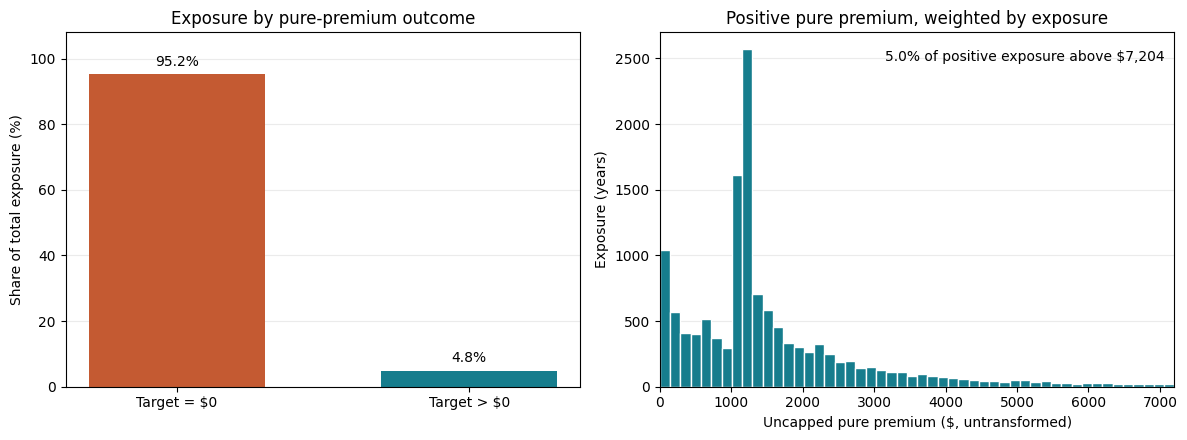

In [3]:
response_plots = mu.plot_pure_premium_distribution(df_train)

Pure premium is exactly $0 for 95.2% of training exposure, creating a large point mass at zero. The positive values are extremely right-skewed: most are comparatively small, while a thin tail reaches much higher values; the histogram calls out the tail beyond its focused display range.

## Interesting Feature 1: Area (Categorical)

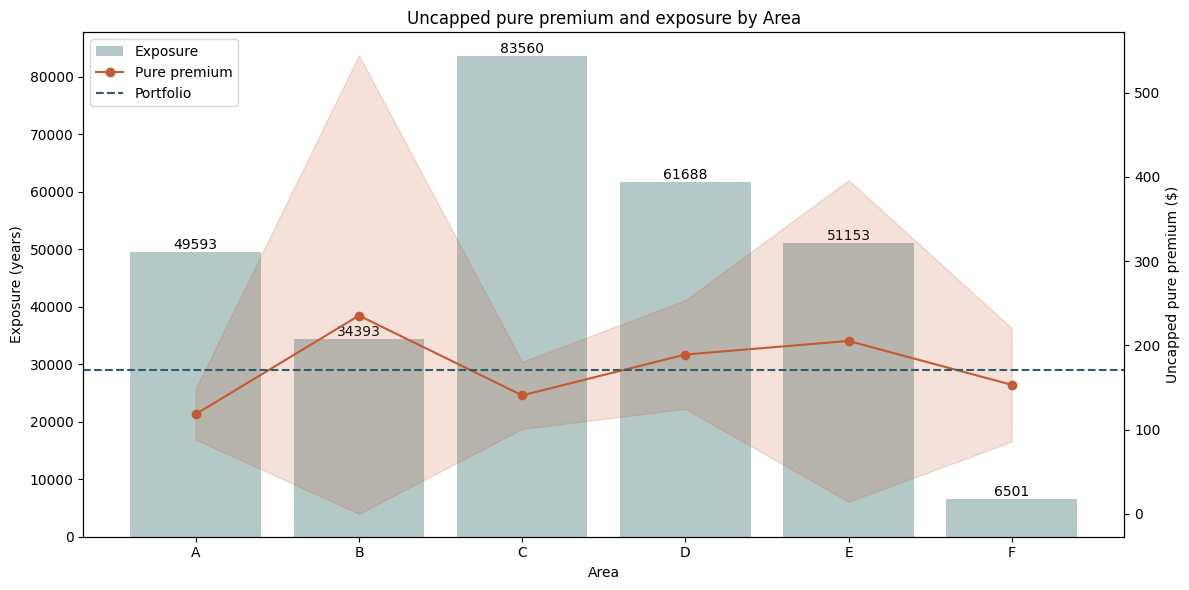

In [4]:
area_1way = mu.plot_area_one_way(df_train)

The bars show exposure by Area; the line shows observed pure premium (losses per exposure), with a ±1 SE band and the portfolio average for reference. Area F has little exposure, while Area B has much greater loss variability and the widest uncertainty band. Low volume in F and high volatility in B both make their observed costs difficult to interpret as true expected loss.

## Interesting Feature 2: BonusMalus (Numeric)

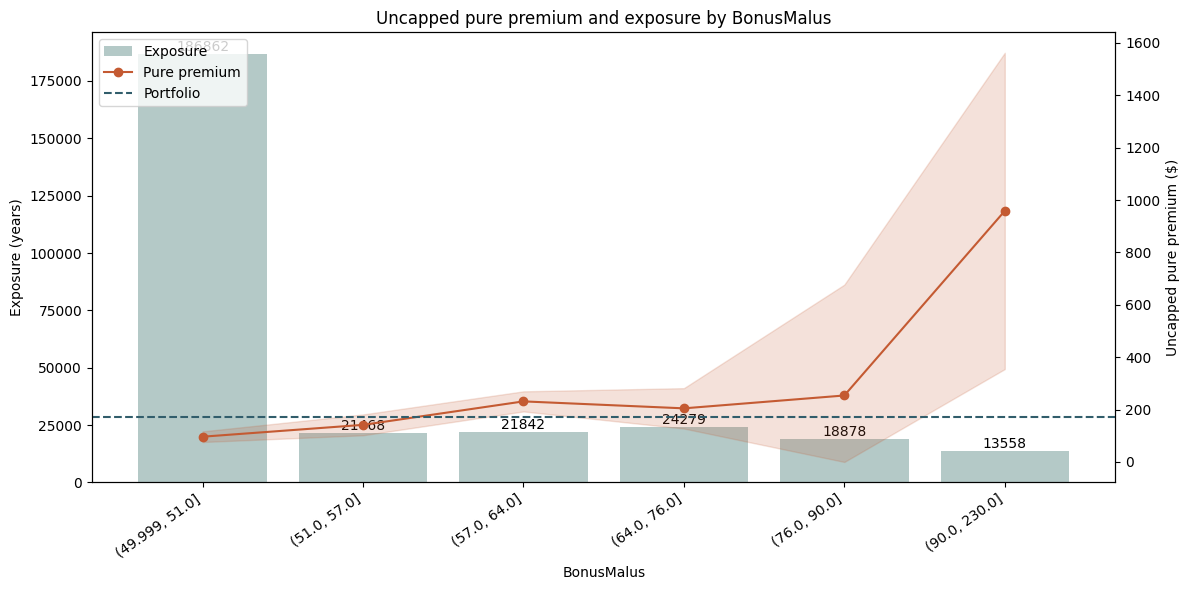

In [5]:
bonusmalus_1way = mu.plot_bonus_malus_one_way(df_train)

Pure premium does not change at a constant rate across BonusMalus ranges; it rises sharply in the highest range. A straight-line effect would miss this curvature, so BonusMalus needs a quadratic or cubic term.

# Modeling

We will fit three models for pure premium: ordinary least squares (OLS), a Tweedie generalized linear model (GLM), and gradient boosting (GBM). Across all three, we will use the same nine rating features:

- **Categorical:** Area, VehBrand, VehGas, and Region.
- **Numeric:** VehPower, VehAge, DrivAge, BonusMalus, and Density.

We will compare predictions on the unseen test set using lift charts to see how well each model ranks risks by observed loss cost.

## Ordinary Least Squares (OLS)

OLS models the capped pure premium as a linear combination of numeric predictors and indicator terms for categorical predictors. With each categorical factor using a reference level, the fitted value is:

$$
\begin{aligned}
\widehat{Y}_i &= \hat{\beta}_0
+ \hat{\beta}_1\,\text{VehPower}_i
+ \hat{\beta}_2\,\text{VehAge}_i
+ \hat{\beta}_3\,\text{DrivAge}_i
+ \hat{\beta}_4\,\text{BonusMalus}_i
+ \hat{\beta}_5\,\text{Density}_i \\
&\quad + \sum_{g \in \{\text{Area},\,\text{VehBrand},\,\text{VehGas},\,\text{Region}\}}
\sum_{\ell \ne \ell_{g,0}} \hat{\gamma}_{g,\ell}\,\mathbb{1}(x_{ig}=\ell),
\end{aligned}
$$

where $Y_i=\text{pure\_premium\_capped\_1MIL}_i$ and $\ell_{g,0}$ is the reference level for factor $g$. OLS chooses the coefficient estimates by minimizing squared residuals:

$$
\widehat{\boldsymbol{\theta}}
= \arg\min_{\boldsymbol{\theta}}
\sum_{i=1}^{n}\left(Y_i-\mathbf{x}_i^{\mathsf{T}}\boldsymbol{\theta}\right)^2,
\qquad \boldsymbol{\theta}=(\boldsymbol{\beta},\boldsymbol{\gamma}),
$$

where $\mathbf{x}_i$ contains the intercept, numeric predictors, and categorical indicators.

In [6]:
ols = mu.fit_ols_model(df_train)

In [7]:
print(ols.summary())

                               OLS Regression Results                               
Dep. Variable:     pure_premium_capped_1MIL   R-squared:                       0.000
Model:                                  OLS   Adj. R-squared:                  0.000
Method:                       Least Squares   F-statistic:                     1.984
Date:                      Sat, 26 Sep 2026   Prob (F-statistic):           0.000152
Time:                              06:59:31   Log-Likelihood:            -6.3971e+06
No. Observations:                    542410   AIC:                         1.279e+07
Df Residuals:                        542367   BIC:                         1.279e+07
Df Model:                                42                                         
Covariance Type:                  nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

Statsmodels fit the model without an exception or runtime warning, but successful execution does not mean it is appropriate. The summary shows virtually no explanatory power ($R^2 \approx 0$) and extreme residual non-normality (skew 405, kurtosis over 210,000). It also flags a large condition number ($1.03 \times 10^5$), suggesting possible multicollinearity or numerical issues. The small overall F-test p-value does not make this a useful predictive model.

The summary raises concerns if you know how to understand it, but why does this matter? Before we keep going, what assumptions does OLS rely on?

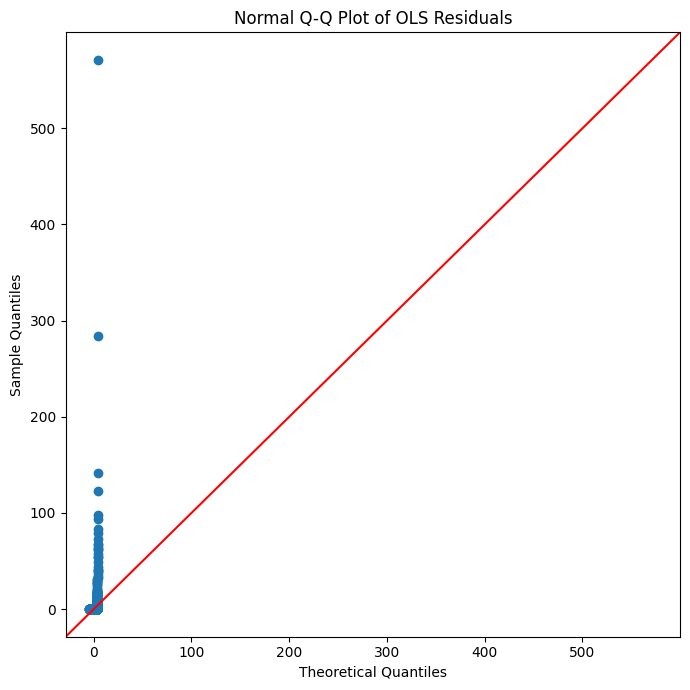

In [8]:
ols_qq = mu.plot_ols_residual_qq(ols)

The Q-Q plot shows a strong departure from normality.

In [9]:
mu.lowest_negative_ols_fits(ols)

,Fitted pure premium
131057,-927.553123
43221,-915.685883
43222,-915.685883
61613,-665.486997
82497,-618.210978
82498,-618.210978
536337,-616.237754
401152,-604.370514
241711,-592.503273
145428,-592.379954


More importantly for a loss-cost model, OLS can predict negative values, which have no practical meaning. It doesn't make sense for an insured to have *negative* losses.

Quick side story: In my first modeling project, I inherited a production loss-cost model built with OLS. It was already being used, even though it could predict negative loss costs. Fixing that was one of the first things I did.

## Generalized Linear Model (GLM)

Unlike OLS, a GLM does not assume normally distributed errors: we choose a response distribution and link suited to the data. For loss costs, a useful distribution you may not have encountered is Tweedie. With variance power $1<p<2$, it can represent a point mass at zero and a continuous, right-skewed positive tail. Here we use $p=1.85$ with a log link.

For capped pure premium $Y_i=\text{pure\_premium\_capped\_1MIL}_i$, let $\mu_i=\mathbb{E}[Y_i\mid X_i]$. The Tweedie variance is $\operatorname{Var}(Y_i\mid X_i)=\phi\mu_i^{1.85}$, and the fitted mean is:

$$
\begin{aligned}
\log(\widehat{\mu}_i) &= \widehat{\eta}_i \\
&= \widehat{\beta}_0
+ \widehat{\beta}_1\,\text{VehPower}_i
+ \widehat{\beta}_2\,\text{VehAge}_i
+ \widehat{\beta}_3\,\text{DrivAge}_i
+ \widehat{\beta}_4\,\text{BonusMalus}_i
+ \widehat{\beta}_5\,\text{Density}_i \\
&\quad + \sum_{g \in \{\text{Area},\,\text{VehBrand},\,\text{VehGas},\,\text{Region}\}}
\sum_{\ell \ne \ell_{g,0}} \widehat{\gamma}_{g,\ell}\,\mathbb{1}(x_{ig}=\ell), \\
\widehat{\mu}_i &= \exp(\widehat{\eta}_i)>0.
\end{aligned}
$$

Categorical factors use reference levels, while numeric predictors enter linearly. The coefficients are estimated by maximizing the Tweedie likelihood, rather than by minimizing squared residuals.

In [10]:
glm = mu.fit_tweedie_glm(df_train)

In [11]:
print(glm.summary())

                    Generalized Linear Model Regression Results                     
Dep. Variable:     pure_premium_capped_1MIL   No. Observations:               542410
Model:                                  GLM   Df Residuals:                   542367
Model Family:                       Tweedie   Df Model:                           42
Link Function:                          Log   Scale:                          4257.9
Method:                                IRLS   Log-Likelihood:            -3.1548e+05
Date:                      Sat, 26 Sep 2026   Deviance:                   1.8870e+07
Time:                              07:00:48   Pearson chi2:                 2.31e+09
No. Iterations:                          90   Pseudo R-squ. (CS):          0.0003753
Covariance Type:                  nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------

Many category-level Wald tests are not significant. Along with the thin Area groups we saw in EDA, that suggests we may want to combine some categories into broader, more credible buckets.

BonusMalus was entered as a single linear term, even though EDA showed a curved relationship; a quadratic or cubic term may fit it better. We also have not modeled interactions- for example, BonusMalus may affect pure premium differently across Areas.

A GLM can represent these patterns, but only when we specify them. Choosing the right structure takes modeling judgment and time, and it may not be obvious in advance. What if a model could discover these patterns for us?

## Gradient Boosting (GBM)

The GLM can capture nonlinear effects and interactions, but only if we choose and specify them. A GBM can learn many of these patterns from the data.

- **Trees:** A decision tree asks a sequence of yes/no questions about a risk, such as whether its BonusMalus is above a threshold. Each split creates groups with different loss experience; a policy's path ends at a leaf that contributes to its prediction.
- **Boosting:** Rather than rely on one large tree, boosting adds many small trees in sequence. Each new tree focuses on what the current ensemble still misses. Their combined contributions can capture curves and interactions without us manually writing every term.
- **Tuning:** Tree depth, minimum group size, learning rate, and number of trees control model complexity. We use cross-validation with Optuna to search these settings for good performance on unseen data, not just a close fit to training data.
- **Interpretation:** Unlike a GLM, a GBM has no compact coefficient table; each prediction combines contributions from many trees. Interpretability tools such as SHAP can help explain the model, but we won't go into them here.

In [12]:
gbm, gbm_study, gbm_rounds, gbm_categories = mu.tune_and_fit_xgb_tweedie(df_train)

[I 2026-09-26 07:00:49,502] A new study created in memory with name: no-name-d20ebcfa-30b9-46b2-a0c8-d6aebe8184fe
[I 2026-09-26 07:00:52,519] Trial 0 finished with value: 224.96625680874246 and parameters: {'tweedie_variance_power': 1.25, 'eta': 0.13, 'max_depth': 5, 'min_child_weight': 17709, 'gamma': 1.0, 'subsample': 0.6, 'colsample_bytree': 0.8500000000000001, 'lambda': 2.0, 'alpha': 3.5, 'max_delta_step': 5.0, 'max_cat_to_onehot': 9, 'max_cat_threshold': 50}. Best is trial 0 with value: 224.96625680874246.
[I 2026-09-26 07:01:03,781] Trial 1 finished with value: 20.67063459092531 and parameters: {'tweedie_variance_power': 1.7, 'eta': 0.02, 'max_depth': 5, 'min_child_weight': 40121, 'gamma': 8.5, 'subsample': 0.6, 'colsample_bytree': 0.7, 'lambda': 12.0, 'alpha': 0.0, 'max_delta_step': 3.0, 'max_cat_to_onehot': 11, 'max_cat_threshold': 49}. Best is trial 1 with value: 20.67063459092531.
[I 2026-09-26 07:01:09,137] Trial 2 finished with value: 110.65906367181962 and parameters: {'tw

Best CV Tweedie negative log-likelihood: 16.598593
Best boosting rounds: 14
Best parameters: {'objective': 'reg:tweedie', 'eval_metric': 'tweedie-nloglik@1.80', 'base_score': 5.05696907351396, 'tree_method': 'hist', 'device': 'cuda', 'seed': 42}


# Model Comparison: Lift Charts

Each chart evaluates one fitted model on the held-out test set; none is refit here. Policies are sorted by predicted pure premium and grouped into ten roughly equal-exposure deciles, from lowest predicted risk to highest. The lines show actual and predicted pure premium in each group, expressed as a multiple of the test-set average (the dashed line at 1). A useful model should rank risks so actual pure premium generally rises across deciles, while its predicted pure premium tracks the actual values.

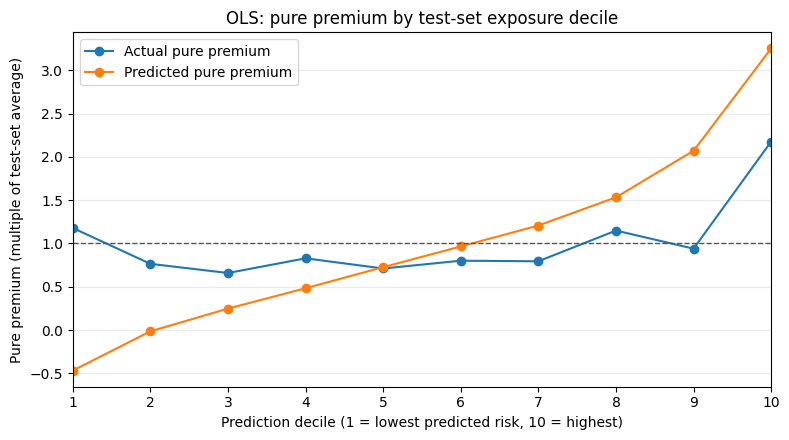

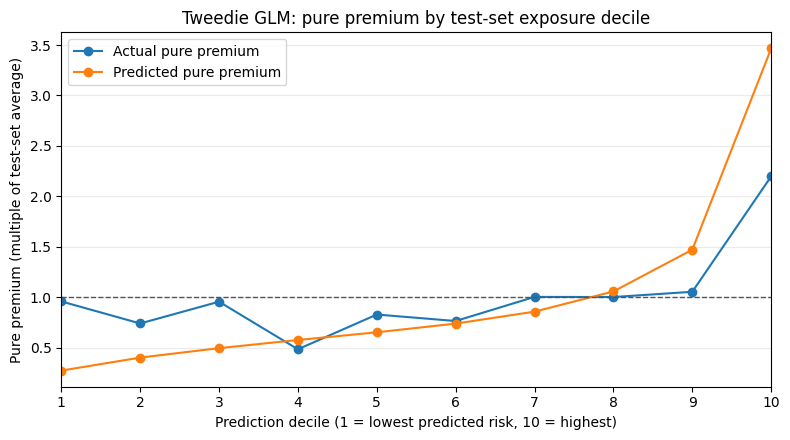

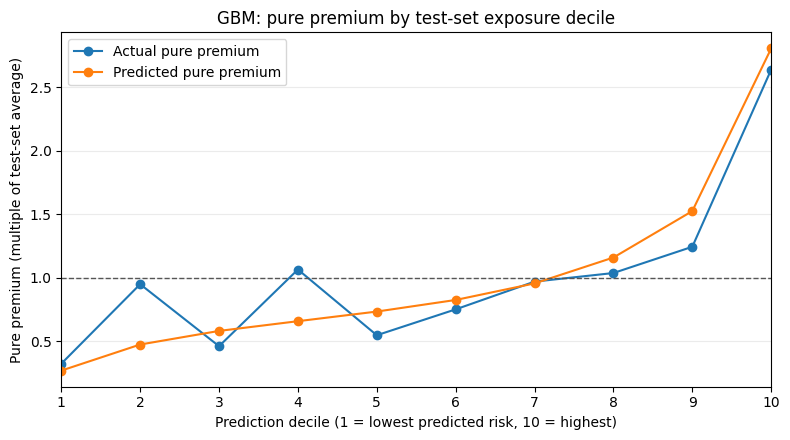

In [13]:
mu.plot_test_model_lifts(df_test, ols, glm, gbm, gbm_categories);

The OLS predictions include negative pure premiums and substantially understate actual experience. The GLM improves on this, but underpredicts the first three deciles and overpredicts the last two, so there is still room to improve. The GBM tracks actual pure premium well overall; Deciles 2 & 4 could be better and deciles 8-10 are somewhat overpredicting.

# Conclusion

The GBM performed best in this comparison, which is not surprising: it can capture nonlinear patterns and interactions that our deliberately simple GLM misses. That does not mean a GLM cannot compete. With thoughtful category grouping, nonlinear terms, and interactions, it could close the gap. We can also use the GBM to spot patterns worth building into a GLM, combining its flexibility with the GLM's clearer structure.